# OrigamiPipeline Tutorial: Training on Real Data

This notebook provides a step-by-step guide to using the `OrigamiPipeline` API for training, saving, and using ORIGAMI models on real-world data.

**What you'll learn:**
1. Loading and exploring JSON data
2. Training with default and custom configurations
3. Saving and loading trained pipelines
4. Making predictions on new data
5. Generating synthetic samples
6. Extracting embeddings for downstream tasks

**Dataset:** We'll use the UCI Car Evaluation dataset, which contains nested JSON objects describing car attributes and their acceptability ratings.

## 1. Setup and Imports

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import numpy as np
import torch

from origami import DataConfig, ModelConfig, OrigamiConfig, OrigamiPipeline, TrainingConfig

# For reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.1


## 2. Load and Explore the Data

The car dataset contains nested JSON objects with car attributes and acceptability ratings.

In [2]:
# Load data from JSONL file
data_path = Path("../datasets/car.jsonl")

with open(data_path) as f:
    raw_data = [json.loads(line) for line in f]

print(f"Loaded {len(raw_data)} records")
print(f"\nSample record:")
print(json.dumps(raw_data[0], indent=2))

Loaded 1728 records

Sample record:
{
  "_id": {
    "$oid": "66c32b7fac3485a3c76f7e74"
  },
  "PRICE": {
    "buying": "vhigh",
    "maint": "vhigh"
  },
  "TECH": {
    "COMFORT": {
      "doors": 2,
      "persons": 2,
      "lug_boot": "small"
    },
    "safety": "low"
  },
  "target": "unacc"
}


In [3]:
# Remove MongoDB _id field (not useful for modeling)
data = [{k: v for k, v in doc.items() if k != "_id"} for doc in raw_data]

print("Cleaned record:")
print(json.dumps(data[0], indent=2))

Cleaned record:
{
  "PRICE": {
    "buying": "vhigh",
    "maint": "vhigh"
  },
  "TECH": {
    "COMFORT": {
      "doors": 2,
      "persons": 2,
      "lug_boot": "small"
    },
    "safety": "low"
  },
  "target": "unacc"
}


In [4]:
# Explore the data structure
print("Data structure:")
print("- PRICE: buying price and maintenance cost")
print("- TECH: technical specs (comfort features + safety)")
print("- target: acceptability rating\n")

# Count target values
target_counts = Counter(d["target"] for d in data)
print("Target distribution:")
for target, count in sorted(target_counts.items()):
    print(f"  {target}: {count} ({count / len(data) * 100:.1f}%)")

Data structure:
- PRICE: buying price and maintenance cost
- TECH: technical specs (comfort features + safety)
- target: acceptability rating

Target distribution:
  acc: 384 (22.2%)
  good: 69 (4.0%)
  unacc: 1210 (70.0%)
  vgood: 65 (3.8%)


In [5]:
# Split into train/eval sets
random.shuffle(data)
split_idx = int(0.8 * len(data))
train_data = data[:split_idx]
eval_data = data[split_idx:]

print(f"Train set: {len(train_data)} records")
print(f"Eval set: {len(eval_data)} records")

Train set: 1382 records
Eval set: 346 records


## 3. Training with Default Configuration

The simplest way to use `OrigamiPipeline` is with default settings. Just create a pipeline and call `fit()`.

In [6]:
# Create pipeline with default config
import json

pipeline = OrigamiPipeline()

# View default configuration
print("Default configuration:")
print(pipeline.config.to_yaml())

Default configuration:
model:
  d_model: 128
  n_heads: 4
  n_layers: 4
  d_ff: 512
  dropout: 0.1
  max_depth: 32
  max_array_position: 256
  kvpe_pooling: sum
  kvpe_pooling_kwargs: {}
  backbone: transformer
  lstm_bidirectional: false
  lstm_num_layers: 2
  use_continuous_head: false
  num_mixture_components: 5
  continuous_loss_weight: -1.0
  use_grammar_constraints: true
  max_seq_length: 2048
training:
  batch_size: 32
  learning_rate: 0.001
  num_epochs: 10
  warmup_steps: 1000
  weight_decay: 0.01
  shuffle_keys: true
  save_every_n_epochs: 5
  checkpoint_dir: null
  eval_strategy: epoch
  eval_steps: 100
  eval_epochs: 1
  eval_metrics: null
  eval_sample_size: null
  eval_on_train: false
  target_key: null
  allow_complex_values: null
data:
  numeric_mode: none
  cat_threshold: 100
  n_bins: 20
  bin_strategy: quantile
  max_vocab_size: 0
device: auto



In [7]:
# Train with defaults (quick training for demonstration)
pipeline.fit(train_data, eval_data=eval_data, epochs=10)

print(f"\nTraining complete!")
print(f"Model parameters: {pipeline._model.get_num_parameters():,}")

Training on mps
Train samples: 1382
Eval samples: 346
Batch size: 32
Epochs: 10
Total steps: 430



Epoch 1:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 1/10 - loss: 2.5215 - tokens/sec: 25817
Eval: val_loss: 2.2391


Epoch 2:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 2/10 - loss: 1.8437 - tokens/sec: 29209
Eval: val_loss: 1.4395


...

Epoch 8/10 - loss: 0.5533 - tokens/sec: 29546
Eval: val_loss: 0.5177


Epoch 9:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 9/10 - loss: 0.5422 - tokens/sec: 29906
Eval: val_loss: 0.5265


Epoch 10:   0%|          | 0/43 [00:00<?, ?batch/s]

Epoch 10/10 - loss: 0.5374 - tokens/sec: 30297
Eval: val_loss: 0.5205

Training complete!
Model parameters: 835,107


## 4. Training with Custom Configuration

`OrigamiConfig` with nested `ModelConfig`, `TrainingConfig`, and `DataConfig` lets you customize model architecture, training parameters, and preprocessing options.

In [8]:
from origami.training import accuracy

# Create a custom configuration with nested structure
custom_config = OrigamiConfig(
    model=ModelConfig(
        d_model=128,  # Embedding dimension
        n_heads=4,  # Attention heads (must divide d_model)
        n_layers=4,  # Transformer layers
        d_ff=512,  # Feed-forward dimension
        dropout=0.1,  # Dropout rate
        kvpe_pooling="sum",  # How to combine path elements: "sum", "weighted", "gru"
    ),
    training=TrainingConfig(
        batch_size=32,
        learning_rate=1e-3,
        warmup_steps=100,
        shuffle_keys=True,  # Data augmentation via key order shuffling
        eval_strategy="steps",
        eval_steps=100,
        eval_metrics={"acc": accuracy},
        target_key="target",
        eval_sample_size=25,
        eval_on_train=True,  # Evaluate on training data as well
    ),
    data=DataConfig(
        numeric_mode="none",  # Car dataset has no high-cardinality numerics
    ),
)

print("Custom configuration:")
print(f"  d_model: {custom_config.model.d_model}")
print(f"  n_layers: {custom_config.model.n_layers}")
print(f"  batch_size: {custom_config.training.batch_size}")
print(f"  shuffle_keys: {custom_config.training.shuffle_keys}")

Custom configuration:
  d_model: 128
  n_layers: 4
  batch_size: 32
  shuffle_keys: True


In [9]:
from origami.training import TableLogCallback

# Create and train pipeline with custom config
pipeline = OrigamiPipeline(custom_config)
pipeline.fit(
    train_data, eval_data=eval_data, callbacks=[TableLogCallback(print_every=100)], epochs=100
)

print(f"\nTraining complete!")
print(f"Model parameters: {pipeline._model.get_num_parameters():,}")

| step: 100 | epoch: 2 | lr: 9.77e-04 | batch_dt:   18ms | loss: 0.5646 | train_acc: 0.7200 | train_loss: 0.5599 | val_acc: 0.6400 | val_loss: 0.5619 |
| step: 200 | epoch: 4 | lr: 9.53e-04 | batch_dt:   17ms | loss: 0.5407 | train_acc: 0.8000 | train_loss: 0.5209 | val_acc: 0.7600 | val_loss: 0.5260 |
| step: 300 | epoch: 6 | lr: 9.30e-04 | batch_dt:   19ms | loss: 0.5233 | train_acc: 0.7600 | train_loss: 0.5001 | val_acc: 0.7200 | val_loss: 0.5020 |
| step: 400 | epoch: 9 | lr: 9.07e-04 | batch_dt:   18ms | loss: 0.5058 | train_acc: 0.7200 | train_loss: 0.5372 | val_acc: 0.8400 | val_loss: 0.5292 |
| step: 500 | epoch: 11 | lr: 8.84e-04 | batch_dt:   17ms | loss: 0.5095 | train_acc: 0.8400 | train_loss: 0.4893 | val_acc: 0.8400 | val_loss: 0.4970 |
| step: 600 | epoch: 13 | lr: 8.60e-04 | batch_dt:   17ms | loss: 0.5115 | train_acc: 0.8400 | train_loss: 0.4991 | val_acc: 0.8800 | val_loss: 0.4916 |
| step: 700 | epoch: 16 | lr: 8.37e-04 | batch_dt:   19ms | loss: 0.5072 | train_acc: 

## 5. Saving and Loading Pipelines

Trained pipelines can be saved to disk and loaded later. The checkpoint includes the model weights, tokenizer vocabulary, configuration, and any preprocessors.

In [10]:
# Save the trained pipeline
save_path = Path("car_pipeline.pt")
pipeline.save(save_path)

print(f"Pipeline saved to: {save_path}")
print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")

Pipeline saved to: car_pipeline.pt
File size: 3286.7 KB


In [11]:
# Load the pipeline (demonstrates how to use a saved model)
save_path = Path("car_pipeline.pt")
pipeline = OrigamiPipeline.load(save_path)

print("Loaded pipeline:")
print(pipeline)

# Clean up
# save_path.unlink()
# print(f"\nCleaned up {save_path}")

Loaded pipeline:
OrigamiPipeline(numeric_mode='none', fitted)


## 6. Making Predictions

Use `predict()` to predict a missing field value given the rest of the object. This is useful for classification, imputation, and recommendation tasks.

In [25]:
# Create a test object with missing target
test_obj = {
    "PRICE": {"buying": "low", "maint": "low"},
    "TECH": {"COMFORT": {"doors": 4, "persons": 4, "lug_boot": "big"}, "safety": "high"},
    "target": None,  # We want to predict this
}

print("Test object (target unknown):")
print(json.dumps(test_obj, indent=2))

Test object (target unknown):
{
  "PRICE": {
    "buying": "low",
    "maint": "low"
  },
  "TECH": {
    "COMFORT": {
      "doors": 4,
      "persons": 4,
      "lug_boot": "big"
    },
    "safety": "high"
  },
  "target": null
}


In [26]:
# Predict the target field
prediction = pipeline.predict(test_obj, target_key="target")
print(f"Predicted target: {prediction}")

# Get top-k predictions with probabilities using predict_proba
top_predictions = pipeline.predict_proba(test_obj, target_key="target", top_k=4)
print("\nTop predictions with probabilities:")
for value, prob in top_predictions:
    print(f"  {value}: {prob:.1%}")

Predicted target: vgood

Top predictions with probabilities:
  vgood: 98.6%
  good: 1.1%
  acc: 0.2%
  unacc: 0.0%


In [27]:
# Try different car configurations
test_cases = [
    # Expensive, unsafe car
    {
        "PRICE": {"buying": "vhigh", "maint": "vhigh"},
        "TECH": {"COMFORT": {"doors": 2, "persons": 2, "lug_boot": "small"}, "safety": "low"},
        "target": None,
    },
    # Cheap, safe family car
    {
        "PRICE": {"buying": "low", "maint": "low"},
        "TECH": {"COMFORT": {"doors": 4, "persons": "more", "lug_boot": "big"}, "safety": "high"},
        "target": None,
    },
    # Medium everything
    {
        "PRICE": {"buying": "med", "maint": "med"},
        "TECH": {"COMFORT": {"doors": 4, "persons": 4, "lug_boot": "med"}, "safety": "med"},
        "target": None,
    },
]

print("Predictions for different car configurations:")
print("=" * 60)
for i, test in enumerate(test_cases, 1):
    pred = pipeline.predict_proba(test, target_key="target", top_k=2)
    buying = test["PRICE"]["buying"]
    safety = test["TECH"]["safety"]
    print(f"\nCar {i}: buying={buying}, safety={safety}")
    print(f"  Predictions: {pred[0][0]} ({pred[0][1]:.0%}), {pred[1][0]} ({pred[1][1]:.0%})")

Predictions for different car configurations:

Car 1: buying=vhigh, safety=low
  Predictions: unacc (100%), acc (0%)

Car 2: buying=low, safety=high
  Predictions: vgood (99%), good (1%)

Car 3: buying=med, safety=med
  Predictions: acc (99%), good (1%)


In [28]:
# Batch prediction for efficiency
batch_results = pipeline.predict_batch(test_cases, target_key="target")

print("Batch predictions:")
for i, (result, _test) in enumerate(zip(batch_results, test_cases, strict=True), 1):
    print(f"  Car {i}: {result}")

Batch predictions:
  Car 1: unacc
  Car 2: vgood
  Car 3: acc


## 7. Generating Synthetic Samples

Use `generate()` to sample new JSON objects from the learned distribution. This is useful for data augmentation, synthetic data generation, and understanding what the model has learned.

In [29]:
# Generate synthetic car records
generated = pipeline.generate(num_samples=5, seed=42)

print("Generated car records:")
print("=" * 60)
for i, sample in enumerate(generated, 1):
    print(f"\nSample {i}:")
    print(json.dumps(sample, indent=2))

Generated car records:

Sample 1:
{
  "target": "unacc",
  "TECH": {
    "safety": "low",
    "COMFORT": {
      "persons": 2,
      "doors": 4,
      "lug_boot": "big"
    }
  },
  "PRICE": {
    "maint": "low",
    "buying": "vhigh"
  }
}

Sample 2:
{
  "target": "unacc",
  "PRICE": {
    "buying": "med",
    "maint": "high"
  },
  "TECH": {
    "safety": "low",
    "COMFORT": {
      "lug_boot": "med",
      "persons": 2,
      "doors": 4
    }
  }
}

Sample 3:
{
  "PRICE": {
    "maint": "med",
    "buying": "vhigh"
  },
  "target": "unacc",
  "TECH": {
    "COMFORT": {
      "doors": "5more",
      "persons": 2,
      "lug_boot": "small"
    },
    "safety": "low"
  }
}

Sample 4:
{
  "target": "unacc",
  "TECH": {
    "COMFORT": {},
    "safety": "5more"
  },
  "PRICE": {
    "maint": "vhigh",
    "buying": "high"
  }
}

Sample 5:
{
  "PRICE": {
    "maint": "low",
    "buying": "vhigh"
  },
  "target": "unacc",
  "TECH": {
    "safety": "high",
    "COMFORT": {
      "persons": 

In [30]:
# Generate with temperature control
# Lower temperature = more deterministic, higher = more diverse

print("Effect of temperature on generation:")
print("=" * 60)

for temp in [0.5, 1.0, 1.5]:
    samples = pipeline.generate(num_samples=3, temperature=temp, seed=123)
    targets = [s.get("target", "?") for s in samples]
    print(f"\nTemperature {temp}: targets = {targets}")

Effect of temperature on generation:

Temperature 0.5: targets = ['acc', 'unacc', 'acc']

Temperature 1.0: targets = ['unacc', 'unacc', 'acc']

Temperature 1.5: targets = ['unacc', 'unacc', 'acc']


In [31]:
# Generate many samples and analyze distribution
many_samples = pipeline.generate(num_samples=100, seed=42)

# Compare generated vs training distribution
gen_targets = Counter(s.get("target", "unknown") for s in many_samples)
train_targets = Counter(d["target"] for d in train_data)

print("Target distribution comparison:")
print(f"{'Target':<10} {'Training':>12} {'Generated':>12}")
print("-" * 36)
for target in sorted(set(train_targets.keys()) | set(gen_targets.keys())):
    train_pct = train_targets.get(target, 0) / len(train_data) * 100
    gen_pct = gen_targets.get(target, 0) / len(many_samples) * 100
    print(f"{target:<10} {train_pct:>11.1f}% {gen_pct:>11.1f}%")

Target distribution comparison:
Target         Training    Generated
------------------------------------
acc               22.1%        24.0%
good               3.8%         3.0%
unacc             70.4%        69.0%
vgood              3.6%         4.0%


## 8. Extracting Embeddings

Use `embed()` to get dense vector representations of JSON objects. These embeddings can be used for clustering, similarity search, visualization, or as features for downstream models.

In [32]:
# Get embedding for a single object
sample_obj = train_data[0]
embedding = pipeline.embed(sample_obj)

print(f"Embedding shape: {embedding.shape}")
print(f"Embedding (first 10 dims): {embedding[:10].tolist()}")

Embedding shape: (128,)
Embedding (first 10 dims): [0.0892937183380127, -0.07557578384876251, 0.12279847264289856, 0.07688943296670914, -0.04438292607665062, -0.03412595018744469, -0.05216696485877037, -0.030688123777508736, 0.11804282665252686, 0.036763329058885574]


In [33]:
# Different pooling strategies
print("Pooling strategies:")
for pooling in ["mean", "max", "last"]:
    emb = pipeline.embed(sample_obj, pooling=pooling)
    print(f"  {pooling}: shape={emb.shape}, norm={np.linalg.norm(emb):.3f}")

Pooling strategies:
  mean: shape=(128,), norm=1.000
  max: shape=(128,), norm=1.000
  last: shape=(128,), norm=1.000


In [34]:
# Batch embedding for efficiency
batch_objects = train_data[:10]
embeddings = pipeline.embed_batch(batch_objects)

print(f"Batch embeddings shape: {embeddings.shape}")

Batch embeddings shape: (10, 128)


In [35]:
# Compute similarity between car records
from sklearn.metrics.pairwise import cosine_similarity

# Get embeddings for some eval samples
sample_cars = eval_data[:20]
car_embeddings = pipeline.embed_batch(sample_cars)

# Compute cosine similarity matrix
similarity = cosine_similarity(car_embeddings)

print(f"Similarity matrix shape: {similarity.shape}")
print("\nMost similar pairs (excluding self):")

# Find most similar pairs
similarity_no_diag = similarity.copy()
np.fill_diagonal(similarity_no_diag, -1)

for _ in range(3):
    max_idx = np.argmax(similarity_no_diag)
    i, j = max_idx // 20, max_idx % 20
    sim = similarity_no_diag[i, j]
    similarity_no_diag[i, j] = -1
    similarity_no_diag[j, i] = -1

    car_i_target = sample_cars[i]["target"]
    car_j_target = sample_cars[j]["target"]
    print(f"  Cars {i} ({car_i_target}) and {j} ({car_j_target}): similarity = {sim:.3f}")

Similarity matrix shape: (20, 20)

Most similar pairs (excluding self):
  Cars 4 (unacc) and 13 (unacc): similarity = 0.997
  Cars 3 (unacc) and 12 (unacc): similarity = 0.995
  Cars 0 (unacc) and 1 (unacc): similarity = 0.994


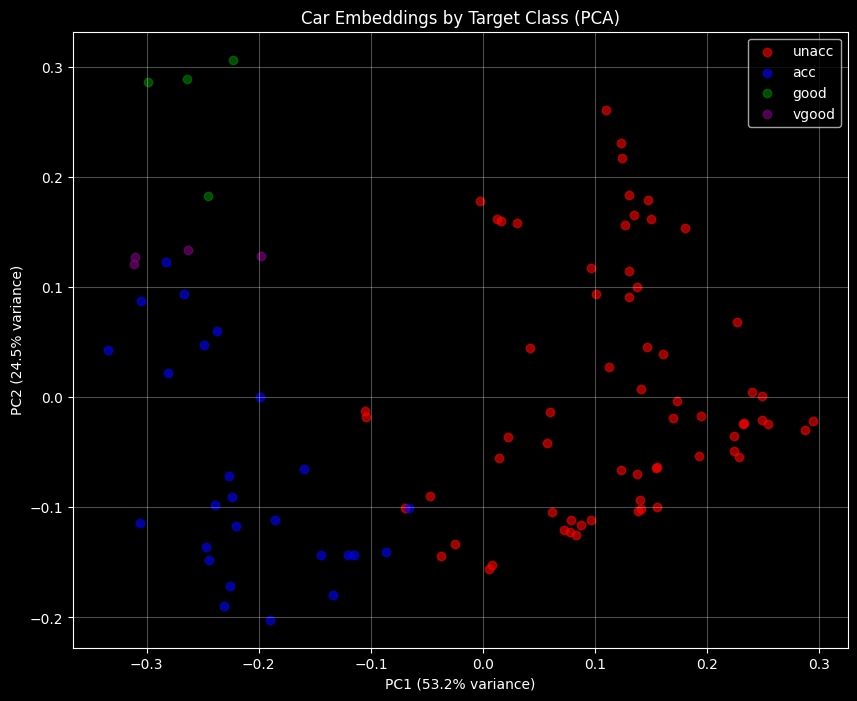

In [36]:
# Visualize embeddings with PCA
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Get embeddings for more samples
viz_samples = eval_data[:100]
viz_embeddings = pipeline.embed_batch(viz_samples)  # Already numpy array
viz_targets = [s["target"] for s in viz_samples]

# Reduce to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(viz_embeddings)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

colors = {"unacc": "red", "acc": "blue", "good": "green", "vgood": "purple"}
for target in colors:
    mask = [t == target for t in viz_targets]
    points = embeddings_2d[mask]
    if len(points) > 0:
        ax.scatter(points[:, 0], points[:, 1], c=colors[target], label=target, alpha=0.6)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Car Embeddings by Target Class (PCA)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 9. Summary

This notebook demonstrated the key features of `OrigamiPipeline`:

### Configuration
```python
# Default config
pipeline = OrigamiPipeline()

# Custom config with nested structure
config = OrigamiConfig(
    model=ModelConfig(d_model=128, n_layers=4),
    training=TrainingConfig(batch_size=32, learning_rate=1e-3),
    data=DataConfig(numeric_mode="none"),
)
pipeline = OrigamiPipeline(config)
```

### Training
```python
pipeline.fit(train_data, eval_data=eval_data, epochs=10)
```

### Save/Load
```python
pipeline.save("model.pt")
pipeline = OrigamiPipeline.load("model.pt")
```

### Prediction
```python
# Single prediction (returns the value directly)
result = pipeline.predict(obj, target_key="field")

# Get probability distribution
probs = pipeline.predict_proba(obj, target_key="field")  # Returns dict

# Get top-k predictions with probabilities
top_k = pipeline.predict_proba(obj, target_key="field", top_k=5)  # Returns list of tuples

# Batch prediction (returns list of values)
results = pipeline.predict_batch(objects, target_key="field")
```

### Generation
```python
samples = pipeline.generate(num_samples=10, temperature=1.0, seed=42)
```

### Embeddings
```python
# Single embedding
emb = pipeline.embed(obj, pooling="mean")

# Batch embeddings
embs = pipeline.embed_batch(objects)
```

### Key Parameters
| Config | Parameter | Description | Default |
|--------|-----------|-------------|---------|
| `ModelConfig` | `d_model` | Embedding dimension | 128 |
| `ModelConfig` | `n_layers` | Transformer layers | 4 |
| `ModelConfig` | `n_heads` | Attention heads | 4 |
| `DataConfig` | `numeric_mode` | "none", "discretize", "scale" | "none" |
| `TrainingConfig` | `shuffle_keys` | Key order augmentation | True |